### Read-in downloaded data

In [1]:
import os
import logging
import time

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_recommenders as tfrs

In [2]:
class UserModel(tf.keras.Model) :

    def __init__(self, conf):
        super().__init__()

        self.gender_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=conf['unique_genders'], mask_token=None),
            tf.keras.layers.Embedding(len(conf['unique_genders']) + 1, 4),
        ])

        self.lang_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                 vocabulary=conf['unique_langs'], mask_token=None),
            tf.keras.layers.Embedding(len(conf['unique_langs']) + 1, 10),
        ])

        self.country_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=conf['unique_countries'], mask_token=None),
            tf.keras.layers.Embedding(len(conf['unique_countries']) + 1, 10),
        ])

        self.network_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=conf['unique_networks'], mask_token=None),
            tf.keras.layers.Embedding(len(conf['unique_networks']) + 1, 4),
        ])

        age_boundaries = np.array([18, 25, 30, 35, 40, 45, 50, 55, 60, 65, float("inf")])
        self.viewer_age_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.Discretization(age_boundaries.tolist()),
            tf.keras.layers.Embedding(len(age_boundaries), 2)
        ])

        self.centroids = tf.constant(conf['centroids'])
        self.viewer_lat_long_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.TextVectorization(
                standardize = None, split = self.classify,
                vocabulary = [str(i) for i in range(len(self.centroids))],
                max_tokens=len(self.centroids) + 2
                ),
            tf.keras.layers.Embedding(len(self.centroids) + 2, 2),
        ])

    @tf.function()
    def call(self, inputs):
        return tf.concat([
            self.gender_embedding(inputs["viewer_gender"]),
            self.lang_embedding(inputs["viewer_lang"]),
            self.country_embedding(inputs["viewer_country"]),
            self.network_embedding(inputs["viewer_network"]),
            self.viewer_age_embedding(inputs["viewer_age"]),
            self.viewer_lat_long_embedding(inputs["viewer_lat_long"]),
        ], axis = 1)

    @tf.keras.utils.register_keras_serializable()
    def classify(self, pair):
        """
        given a datapoint, compute the cluster closest to the datapoint. Return the cluster ID of that cluster.
        :param pair:
        :return: cluster ID
        """
        str_data = tf.strings.split(pair, sep = ",").values
        str_data = tf.map_fn(lambda x: tf.strings.regex_replace(x, "b'", ""), str_data)
        datapoints = tf.map_fn(lambda x: tf.strings.to_number(x), str_data, dtype = (tf.float32))
        datapoints = tf.reshape(datapoints, [-1, 2])

        expanded_centroids = tf.expand_dims(self.centroids, 1)
        expanded_vectors = tf.expand_dims(datapoints, 0)
        distances = tf.reduce_sum(tf.square(tf.subtract(expanded_vectors, expanded_centroids)), 2)
        clusters = tf.math.argmin(distances)
        return tf.strings.as_string(clusters)

In [3]:
class QueryModel(tf.keras.Model):
	"""Model for encoding user queries."""

	def __init__(self, conf):
		"""Model for encoding user queries.

		Args:
		  layer_sizes:
			A list of integers where the i-th entry represents the number of units
			the i-th layer contains.
		"""
		super().__init__()

		# We first use the user model for generating embeddings.
		self.embedding_model = UserModel(conf)
		self.dense_layers = tf.keras.Sequential(
			[
				tf.keras.layers.Dense(32, activation = 'relu', kernel_regularizer = tf.keras.regularizers.L2(0.0001)),
				tf.keras.layers.Dense(32)
			]
		)

	def call(self, inputs):
		feature_embedding = self.embedding_model(inputs)
		return self.dense_layers(feature_embedding)

In [4]:
class BroadcasterModel(tf.keras.Model):

    def __init__(self, conf):
        super().__init__()

        self.broadcaster_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=conf['unique_broadcasters'], mask_token=None),
            tf.keras.layers.Embedding(len(conf['unique_broadcasters']) + 1, conf['broadcaster_embedding_dimension'])
        ])

    def call(self, broadcaster):
        return tf.concat([
            self.broadcaster_embedding(broadcaster),
        ], axis=1)

In [5]:
class CandidateModel(tf.keras.Model):
	"""Model for encoding movies."""

	def __init__(self, conf):
		"""Model for encoding movies.
	
		Args:
		  layer_sizes:
			A list of integers where the i-th entry represents the number of units
			the i-th layer contains.
		"""
		super().__init__()

		self.embedding_model = BroadcasterModel(conf)
            
		self.dense_layers = tf.keras.Sequential(
			[
				tf.keras.layers.Dense(32, activation = 'relu', kernel_regularizer = tf.keras.regularizers.L2(0.0001)),
				tf.keras.layers.Dropout(0.5),
				tf.keras.layers.Dense(32)
			]
		)   

	def call(self, inputs):
		feature_embedding = self.embedding_model(inputs)
		return self.dense_layers(feature_embedding)

In [6]:
class RankingModel(tf.keras.Model):

	def __init__(self):
		super().__init__()
		embedding_dimension = 32

		# Compute predictions.
		self.ratings = tf.keras.Sequential(
			[
				# Learn multiple dense layers.
				tf.keras.layers.Dense(256, activation = "relu"),
				tf.keras.layers.Dense(64, activation = "relu"),
				# Make rating predictions in the final layer.
				tf.keras.layers.Dense(1)
			]
		)

	def call(self, inputs):
		query_embeddings, positive_broadcaster_embeddings = inputs
		return self.ratings(tf.concat([query_embeddings, positive_broadcaster_embeddings], axis = 1))

### Load Data

In [7]:
def load_data_file_cold(file, stats):
    print('loading file:' + file)
    training_df = pd.read_csv(
        file,
        skiprows=[0],
        names=["viewer",
               "broadcaster",
               "viewer_age",
               "viewer_gender",
               "viewer_longitude",
               "viewer_latitude",
               "viewer_lang",
               "viewer_country",
               "broadcaster_age",
               "broadcaster_gender",
               "broadcaster_longitude",
               "broadcaster_latitude",
               "broadcaster_lang",
               "broadcaster_country",
               "duration", 
               "viewer_network", 
               "broadcaster_network", 
               "count"], 
        dtype={
            'viewer': np.unicode,
            'broadcaster': np.unicode,
            'viewer_age': np.single,
            'viewer_gender': np.unicode,
            'viewer_longitude': np.single,
            'viewer_latitude': np.single,
            'viewer_lang': np.unicode,
            'viewer_country': np.unicode,
            'broadcaster_age': np.single,
            'broadcaster_longitude': np.single,
            'broadcaster_latitude': np.single,
            'broadcaster_lang': np.unicode,
            'broadcaster_country': np.unicode,
            'duration': np.single,
            'viewer_network': np.unicode,
            'broadcaster_network': np.unicode,
            'count': np.unicode,
        })

    values = {
        'viewer': 'unknown',
        'broadcaster': 'unknown',
        'viewer_age': 30,
        'viewer_gender': 'unknown',
        'viewer_longitude': 0,
        'viewer_latitude': 0,
        'viewer_lang': 'unknown',
        'viewer_country': 'unknown',
        'broadcaster_age': 30,
        'broadcaster_longitude': 0,
        'broadcaster_latitude': 0,
        'broadcaster_lang': 'unknown',
        'broadcaster_country': 'unknown',
        'duration': 13,
        'viewer_network': 'unknown',
        'broadcaster_network': 'unknown',
        "viewer_lat_long": tf.constant(["40.36393,-74.89611"]),
        'count': '1'
    }

    training_df = training_df.sample(frac=0.1)
    training_df.fillna(value=values, inplace=True)
    training_df['viewer_lat_long'] = training_df[['viewer_latitude', 'viewer_longitude']].apply(lambda x: '{},{}'.format(x[0],x[1]), axis=1)
    training_df['duration'] = np.log(training_df['duration'])
    print(training_df.head(10))
    print(training_df.iloc[-10:])
    # stats.send_stats('data-size', len(training_df.index))
    return training_df


def load_training_data_cold(file, stats):
    ratings_df = load_data_file_cold(file, stats)
    print('creating data set')
    training_ds = (
        tf.data.Dataset.from_tensor_slices(
            ({
                "viewer": tf.cast(
                    ratings_df['viewer'].values,
                    tf.string),
                "viewer_gender": tf.cast(
                    ratings_df['viewer_gender'].values,
                    tf.string),
                "viewer_lang": tf.cast(
                    ratings_df['viewer_lang'].values,
                    tf.string),
                "viewer_country": tf.cast(
                    ratings_df['viewer_country'].values,
                    tf.string),
                "viewer_age": tf.cast(
                    ratings_df['viewer_age'].values,
                    tf.int32),
                "viewer_longitude": tf.cast(
                    ratings_df['viewer_longitude'].values,
                    tf.float16),
                "viewer_latitude": tf.cast(
                    ratings_df['viewer_latitude'].values,
                    tf.float16),
                "broadcaster": tf.cast(
                    ratings_df['broadcaster'].values,
                    tf.string),
                "viewer_network": tf.cast(
                    ratings_df['viewer_network'].values,
                    tf.string),
                "broadcaster_network": tf.cast(
                    ratings_df['broadcaster_network'].values,
                    tf.string),
                "duration": tf.cast(
                    ratings_df['duration'].values,
                    tf.float16),
                "viewer_lat_long": tf.cast(
                    ratings_df['viewer_lat_long'].values,
                    tf.string),
            })))

    return training_ds
            

def prepare_training_data_cold(train_ds):
    print('prepare_training_data')
    training_ds = train_ds.cache().map(lambda x: {
        "broadcaster": x["broadcaster"],
        "viewer": x["viewer"],
        "viewer_gender": x["viewer_gender"],
        "viewer_lang": x["viewer_lang"],
        "viewer_country": x["viewer_country"],
        "viewer_age": x["viewer_age"],
        "viewer_longitude": x["viewer_longitude"],
        "viewer_latitude": x["viewer_latitude"],
        "viewer_network": x["viewer_network"],
        "broadcaster_network": x["broadcaster_network"],
        "duration": x["duration"],
        "viewer_lat_long": x["viewer_lat_long"],
    }, num_parallel_calls=tf.data.AUTOTUNE,
       deterministic=False)

    print('done prepare_training_data')
    return training_ds

In [8]:
def get_broadcaster_data_set(train_ds):
    broadcasters = train_ds.cache().map(lambda x: x["broadcaster"], num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)
    broadcasters_ds = tf.data.Dataset.from_tensor_slices(
        np.unique(list(broadcasters.as_numpy_iterator())))
    return broadcasters_ds

In [9]:
!ls csv

0e9cd673-8e06-4810-b370-8b9930ee312a.csv
2021-10-28-cleaned.csv
2021-10-28.csv
2022-01-03.csv
2022-01-07.csv
2022-01-10.csv
2022-01-12.csv
2022-1-10-grp.csv
50c39121-3de2-4b6b-b134-bb51732c1d6f.csv
viewer_lat_long_centroids.csv


In [10]:
training_dataset = load_training_data_cold("csv/2022-01-12.csv", "")

loading file:csv/2022-01-12.csv


2022-01-18 09:39:34.082509: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


                                                   viewer  \
10569759  24 cf 9a 7e c6 17 ef ce fb 40 8c 34 fd 3c 2b a7   
2137458   83 a7 6a ea b1 3d 98 68 54 3e db 21 e2 b9 4d 81   
372509    b1 c9 5c fc ff d0 17 16 76 b8 e0 c3 bf d7 e8 b2   
4302290   c6 de a4 04 cf 41 8e 2a ae 33 77 c2 c3 c9 b4 6b   
6971394   c4 90 36 58 a3 64 c3 8e dd 18 fd e2 01 63 95 f6   
5223626   84 f1 38 5b be b9 67 6f 9b 85 10 3f c6 3b a6 ca   
1484144   e2 ce a1 6f cb 0f 50 fc 5c aa 75 c6 01 2e 23 56   
7568172   f8 e5 1c fe f7 ac 05 47 b4 04 9d 31 f9 0d ce 22   
7138452   46 5b 88 7f 10 15 ce 2d 60 9d cd 60 5b bc 53 af   
9095822   3f 92 66 6a b9 22 05 ff 6e 26 fc 05 ef 87 2d 04   

                                              broadcaster  viewer_age  \
10569759  c9 e2 bc 7b 4e 7f 28 ab a5 11 99 29 98 dc 0a bd        36.0   
2137458   ce 1a 47 8d b0 a7 b0 06 17 6e 5a e7 90 17 d6 71        28.0   
372509    06 09 a2 fb 6b b4 2e dd bc 72 60 ad 46 34 d6 80        51.0   
4302290   08 6c 62 02 33 a2 5d 6f 9f

In [11]:
train = prepare_training_data_cold(training_dataset)

prepare_training_data
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
done prepare_training_data


In [12]:
broadcasters_data_set = get_broadcaster_data_set(training_dataset)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2022-01-18 09:40:03.012830: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:176] None of the MLIR Optimization Passes are enabled (registered 2)


In [13]:
def get_list(training_data, key):
    return training_data.batch(1_000_000).map(lambda x: x[key], num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)


def get_unique_list(data):
    return np.unique(np.concatenate(list(data)))

In [14]:
user_genders = get_list(train, 'viewer_gender')

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [15]:
user_langs = get_list(train, 'viewer_lang')

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [16]:
user_countries = get_list(train, 'viewer_country')

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [17]:
viewer_age = get_list(train, 'viewer_age')

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [18]:
user_networks = get_list(train, 'viewer_network')

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [19]:
broadcaster_ids = get_list(train, 'broadcaster')

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [20]:
unique_user_genders = get_unique_list(user_genders)
len(unique_user_genders)

3

In [21]:
unique_user_langs = get_unique_list(user_langs)
len(unique_user_langs)

63

In [22]:
unique_user_countries = get_unique_list(user_countries)
len(unique_user_countries)

177

In [23]:
unique_user_networks = get_unique_list(user_networks)
len(unique_user_networks)

5

In [24]:
unique_broadcasters = get_unique_list(broadcaster_ids)
len(unique_broadcasters)

81240

In [25]:
broadcaster_embedding_dimension = 32

In [26]:
cold_start_conf = {
    'unique_genders': unique_user_genders,
    'unique_langs': unique_user_langs,
    'unique_countries': unique_user_countries,
    'unique_networks': unique_user_networks,
    'unique_broadcasters': unique_broadcasters,
    'broadcaster_embedding_dimension': broadcaster_embedding_dimension,
    'age_boundaries': [18, 25, 30, 35, 40, 45, 50, 55, 60, 65, float("inf")],
    'centroids': [[36.68147669256268, -82.8910274009993],
        [23.22243322909555, 78.23027450833709],
        [50.04997682638993, 0.22379313938744885],
        [37.9309447099281, -117.00741350764692],
        [-32.795864819917725, 148.7159172660312],
        [-18.570548393114084, -54.280255665692565],
        [13.921140442819565, 116.38740315555172],
        [29.78951080730802, 40.279515865947936]]
}

In [27]:
cold_start_conf

{'unique_genders': array([b'female', b'male', b'unknown'], dtype=object),
 'unique_langs': array([b'ar', b'az', b'bg', b'bm', b'bn', b'bs', b'ca', b'co', b'cs',
        b'da', b'de', b'el', b'en', b'es', b'et', b'eu', b'fa', b'fi',
        b'fr', b'gl', b'gu', b'he', b'hi', b'hr', b'hu', b'id', b'in',
        b'it', b'iw', b'ja', b'km', b'ko', b'lo', b'lt', b'lv', b'ml',
        b'mr', b'ms', b'my', b'nb', b'ne', b'nl', b'ny', b'pa', b'pl',
        b'ps', b'pt', b'ro', b'ru', b'sk', b'sm', b'sq', b'sr', b'sv',
        b'ta', b'te', b'th', b'tr', b'uk', b'ur', b'uz', b'vi', b'zh'],
       dtype=object),
 'unique_countries': array([b'419', b'AC', b'AD', b'AE', b'AF', b'AG', b'AI', b'AL', b'AO',
        b'AQ', b'AR', b'AS', b'AT', b'AU', b'AW', b'AX', b'AZ', b'BA',
        b'BB', b'BD', b'BE', b'BF', b'BG', b'BH', b'BJ', b'BN', b'BO',
        b'BQ', b'BR', b'BS', b'BY', b'BZ', b'CA', b'CH', b'CI', b'CL',
        b'CM', b'CN', b'CO', b'CR', b'CU', b'CV', b'CY', b'CZ', b'DE',
        b'DK',

### Query Model

In [28]:
query_model = QueryModel(cold_start_conf)

### Candidate Model

In [29]:
candidate_model = CandidateModel(cold_start_conf)

In [30]:
metrics = tfrs.metrics.FactorizedTopK(candidates=broadcasters_data_set.batch(128).map(candidate_model))

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

In [31]:
learning_rate = 0.05
batch_size = 16384
# batch_size = 250
epochs = 20
patience = 2
top_k = 1999

In [32]:
tf.random.set_seed(42)
shuffled = train.shuffle(100_000, seed=42, reshuffle_each_iteration=True)

train_p80 = shuffled.take(80_000)
test_p20 = shuffled.skip(80_000).take(20_000)

cached_train = train_p80.shuffle(100_000).batch(batch_size)
cached_test = test_p20.batch(batch_size).cache()

### New User Model with Ranking

In [33]:
retrieval_task = tfrs.tasks.Retrieval(
    metrics=tfrs.metrics.FactorizedTopK(
        candidates=broadcasters_data_set.batch(128).map(candidate_model)
    )
)

In [34]:
ranking_task = tfrs.tasks.Ranking(
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[tf.keras.metrics.RootMeanSquaredError()],
)

In [35]:
from typing import Dict, Text

In [36]:
class TwoTowers(tfrs.models.Model):
    
    def __init__(self, candidate_model, query_model, ranking_model, ranking_task, retrieval_task, ranking_weight, retrieval_weight):
        super().__init__()

        self.query_model: tf.keras.Model = query_model
        self.candidate_model: tf.keras.Model = candidate_model
        self.ranking_model: tf.keras.Model = ranking_model
            
        self.ranking_task = ranking_task
        self.retrieval_task = retrieval_task
        
        # The loss weights.
        self.ranking_weight = ranking_weight
        self.retrieval_weight = retrieval_weight

    def train_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:
        with tf.GradientTape() as tape:
            query_embeddings = self.query_model({
                "viewer_gender": features["viewer_gender"],
                "viewer_lang": features["viewer_lang"],
                "viewer_country": features["viewer_country"],
                "viewer_age": features["viewer_age"],
                "viewer_network": features["viewer_network"],
                "viewer_latitude": features["viewer_latitude"],
                "viewer_longitude": features["viewer_longitude"],
                "viewer_lat_long": features["viewer_lat_long"],
            })
            positive_broadcaster_embeddings = self.candidate_model(
                features["broadcaster"])

            labels = features["duration"]
            ranking_predictions = self.ranking_model(
                (query_embeddings, positive_broadcaster_embeddings)
            )
            ranking_loss = self.ranking_task(
                labels = labels,
                predictions = ranking_predictions,
            )
            retrieval_loss = self.retrieval_task(query_embeddings, positive_broadcaster_embeddings)
            regularization_loss = sum(self.losses)
            total_loss = regularization_loss + self.ranking_weight * ranking_loss + self.retrieval_weight * retrieval_loss

        gradients = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_variables)
        )
        
        metrics = {metric.name: metric.result() for metric in self.metrics}
        metrics["loss"] = ranking_loss 
        metrics["regularization_loss"] = regularization_loss
        metrics["total_loss"] = total_loss
        
        return metrics


    def test_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:
        labels = features["duration"]
        
        query_embeddings = self.query_model({
            "viewer_gender": features["viewer_gender"],
            "viewer_lang": features["viewer_lang"],
            "viewer_country": features["viewer_country"],
            "viewer_age": features["viewer_age"],
            "viewer_network": features["viewer_network"],
            "viewer_latitude": features["viewer_latitude"],
            "viewer_longitude": features["viewer_longitude"],
            "viewer_lat_long": features["viewer_lat_long"],
        })
        positive_broadcaster_embeddings = self.candidate_model(
            features["broadcaster"])
        
        rating_predictions = self.ranking_model(
            (query_embeddings, positive_broadcaster_embeddings)
        )
        
        retrieval_loss = self.retrieval_task(query_embeddings, positive_broadcaster_embeddings)

        # The task computes the loss and the metrics.
        ranking_loss = self.ranking_task(labels = labels, predictions = rating_predictions)
        
        regularization_loss = sum(self.losses)
        
        total_loss = regularization_loss + self.ranking_weight * ranking_loss + self.retrieval_weight * retrieval_loss
        
        metrics = {metric.name: metric.result() for metric in self.metrics}
        metrics["loss"] = ranking_loss + retrieval_loss
        metrics["regularization_loss"] = regularization_loss
        metrics["total_loss"] = total_loss
        return metrics

### Rretrieval-specialized model

In [37]:
ranking_model = RankingModel()

In [38]:
ranking_weight = 0
retrieval_weight = 1

In [39]:
model = TwoTowers(candidate_model, query_model, ranking_model, ranking_task, retrieval_task, ranking_weight, retrieval_weight)

In [40]:
tf.config.run_functions_eagerly(True)

In [41]:
model.compile(
    optimizer=tf.keras.optimizers.Adagrad(learning_rate=learning_rate),
    run_eagerly=True)

In [42]:
learning_rate = 0.01
batch_size = 16384
# batch_size = 250
epochs = 30
patience = 3
top_k = 1999

In [43]:
shuffled = train.shuffle(100_000, seed=42, reshuffle_each_iteration=True)

train = shuffled.take(80_000)
test = shuffled.skip(80_000).take(20_000)

cached_train = train.shuffle(100_000).batch(batch_size).cache()
cached_test = test.batch(batch_size).cache()

In [44]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor='total_loss', 
    patience=patience,
    verbose=1,
    restore_best_weights=True
)
retrieval_model_history = model.fit(
    cached_train,
    validation_data=cached_test,
    validation_freq=5,
    epochs=epochs,
    verbose=0)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

/Users/lhuang/opt/miniconda3/envs/tensorflow2.5/lib/python3.7/site-packages/tensorflow/python/data/ops/dataset_ops.py:3704: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable.debug_mode()`.
  "Even though the `tf.config.experimental_run_functions_eagerly` "


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

...

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

In [45]:
retrieval_model_history.history

{'root_mean_squared_error': [4.526285171508789,
  4.537078380584717,
  4.546352863311768,
  4.5773420333862305,
  4.58615779876709,
  4.587679862976074,
  4.587394714355469,
  4.591679573059082,
  4.586128234863281,
  4.59083366394043],
 'factorized_top_k/top_1_categorical_accuracy': [0.0004625000001396984,
  0.0002500000118743628,
  0.0003000000142492354,
  0.0002125000028172508,
  0.0002125000028172508,
  0.00019999999494757503,
  0.0003000000142492354,
  0.0003375000087544322,
  0.0003499999875202775,
  0.00039999998989515007],
 'factorized_top_k/top_5_categorical_accuracy': [0.0021750000305473804,
  0.0013375000562518835,
  0.0017000000225380063,
  0.0011249999515712261,
  0.0009250000002793968,
  0.0009500000160187483,
  0.0018375000217929482,
  0.0017500000540167093,
  0.0021124999038875103,
  0.0025500000920146704],
 'factorized_top_k/top_10_categorical_accuracy': [0.0034749999176710844,
  0.0027000000700354576,
  0.003037499962374568,
  0.0021250001154839993,
  0.00167499994859

In [47]:
accuracy = retrieval_model_history.history["factorized_top_k/top_100_categorical_accuracy"][-1]
print(f"Top-100 accuracy: {accuracy:.4f}.")

Top-100 accuracy: 0.0409.


### Joint model

In [48]:
ranking_weight = 1
retrieval_weight = 1

In [49]:
joint_model = TwoTowers(candidate_model, query_model, ranking_model, ranking_task, retrieval_task, ranking_weight, retrieval_weight)

In [50]:
joint_model.compile(
    optimizer=tf.keras.optimizers.Adagrad(learning_rate=learning_rate),
    run_eagerly=True)

In [51]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor='total_loss', 
    patience=patience,
    verbose=1,
    restore_best_weights=True
)
joint_model_history = joint_model.fit(
    cached_train,
    validation_data=cached_test,
    validation_freq=5,
    epochs=30,
    verbose=0)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

...

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

In [52]:
joint_model_history.history

{'root_mean_squared_error': [2.971391439437866,
  1.684098482131958,
  1.617263674736023,
  1.574103593826294,
  1.5445964336395264,
  1.5244911909103394,
  1.5123957395553589,
  1.5055367946624756,
  1.501924753189087,
  1.4998302459716797,
  1.4959919452667236,
  1.4933873414993286,
  1.4915335178375244,
  1.4906436204910278,
  1.4894764423370361,
  1.489457607269287,
  1.488701581954956,
  1.4894015789031982,
  1.4882280826568604,
  1.488122582435608,
  1.486824631690979,
  1.486722469329834,
  1.4858494997024536,
  1.4860820770263672,
  1.4855923652648926,
  1.4861135482788086,
  1.4860478639602661,
  1.4870821237564087,
  1.4874951839447021,
  1.488344669342041],
 'factorized_top_k/top_1_categorical_accuracy': [0.0005624999757856131,
  0.0008500000112690032,
  0.0008875000057742,
  0.0009500000160187483,
  0.0011249999515712261,
  0.0011749999830499291,
  0.0013375000562518835,
  0.0013249999610707164,
  0.0012499999720603228,
  0.001537499949336052,
  0.001550000044517219,
  0.00

In [60]:
num_validation_runs = min(10, len(joint_model_history.history["factorized_top_k/top_100_categorical_accuracy"]))

In [61]:
%matplotlib inline
import matplotlib.pyplot as plt

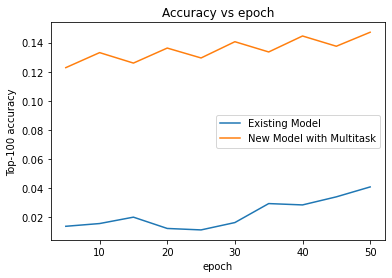

In [65]:
epochs = [(x + 1)* 5 for x in range(num_validation_runs)]

plt.plot(epochs, retrieval_model_history.history["factorized_top_k/top_100_categorical_accuracy"][-num_validation_runs:], label="Existing Model")
plt.plot(epochs, joint_model_history.history["factorized_top_k/top_100_categorical_accuracy"][-num_validation_runs:], label="New Model with Multitask")
plt.title("Accuracy vs epoch")
plt.xlabel("epoch")
plt.ylabel("Top-100 accuracy");
plt.legend()

In [66]:
accuracy = joint_model_history.history["factorized_top_k/top_100_categorical_accuracy"][-1]
print(f"Top-100 accuracy: {accuracy:.4f}.")

Top-100 accuracy: 0.1471.


In [68]:
accuracy = joint_model_history.history["val_factorized_top_k/top_100_categorical_accuracy"][-1]
print(f"Top-100 accuracy: {accuracy:.4f}.")

Top-100 accuracy: 0.0642.


In [70]:
val_accuracy = joint_model_history.history["root_mean_squared_error"][-1]
print(f"Top-100 accuracy: {val_accuracy:.4f}.")

Top-100 accuracy: 1.4883.
